In [39]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [41]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

demand_forecasting_kernels_only_path = kagglehub.competition_download('demand-forecasting-kernels-only')

print('Data source import complete.')


Data source import complete.


In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/demand-forecasting-kernels-only/sample_submission.csv
/kaggle/input/competitions/demand-forecasting-kernels-only/train.csv
/kaggle/input/competitions/demand-forecasting-kernels-only/test.csv


In [43]:
# Uncomment if running locally

!pip install lightgbm
!pip install xgboost
!pip install pmdarima
!pip install catboost
!pip install shap
!pip install tensorflow
!pip install statsmodels
!pip install plotly

In [44]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [45]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [46]:
import os

TEST_PATH = os.path.join(demand_forecasting_kernels_only_path, "test.csv")
TRAIN_PATH = os.path.join(demand_forecasting_kernels_only_path, "train.csv")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(train.shape)
print(test.shape)

(913000, 4)
(45000, 4)


In [47]:
train.head()
train.tail()

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [48]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
store,913000.0,5.500000,2.872283,1.0,3.0,5.5,8.0,10.0
item,913000.0,25.500000,14.430878,1.0,13.0,25.5,38.0,50.0
sales,913000.0,52.250287,28.801144,0.0,30.0,47.0,70.0,231.0


In [49]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [50]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [51]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [52]:
print(train["date"].min())
print(train["date"].max())

2013-01-01 00:00:00
2017-12-31 00:00:00


In [53]:
train["store"].nunique()

10

In [54]:
train["item"].nunique()

50

In [55]:
train.groupby(["store","item"]).ngroups

500

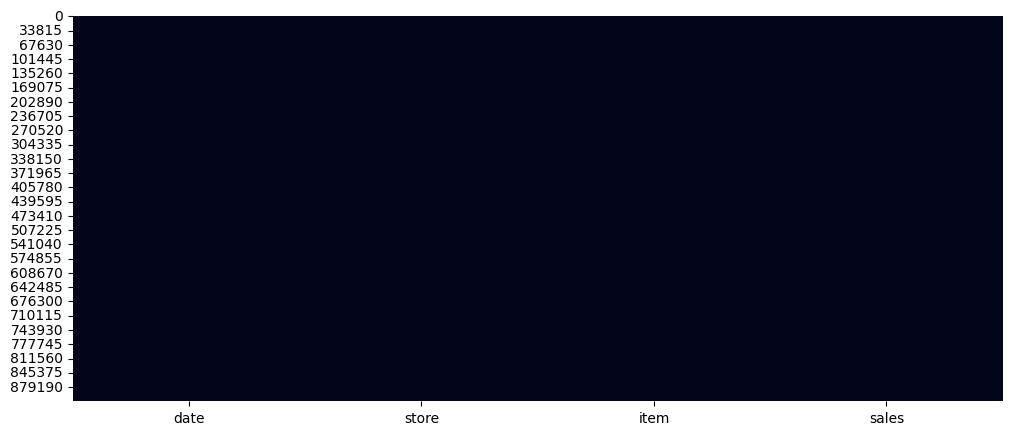

In [56]:
plt.figure(figsize=(12,5))
sns.heatmap(train.isnull(),cbar=False)
plt.show()

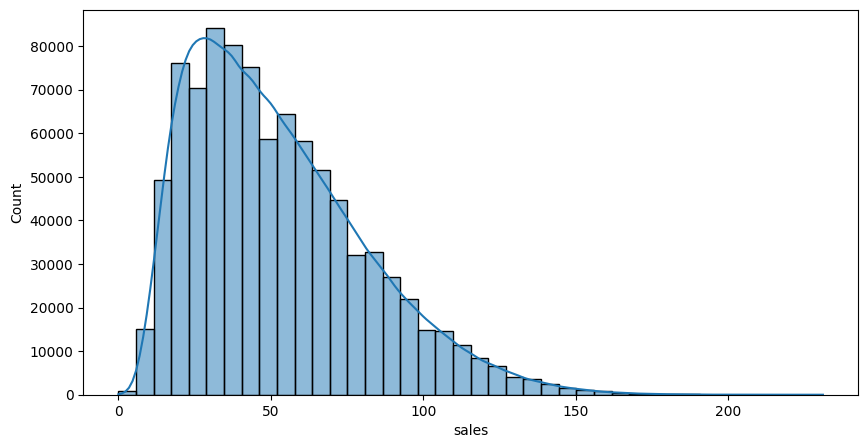

In [57]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["sales"],
    bins=40,
    kde=True
)

plt.show()

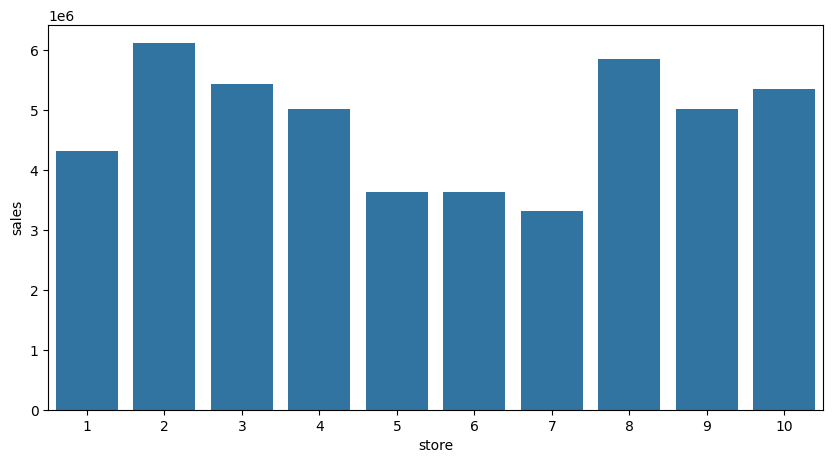

In [58]:
store_sales = (
    train.groupby("store")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x="store",
    y="sales",
    data=store_sales
)

plt.show()

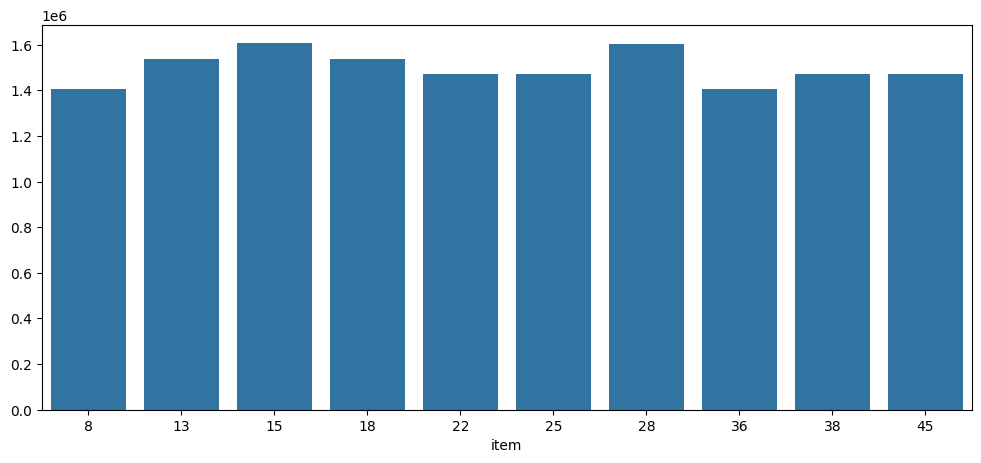

In [59]:
top_items = (
    train.groupby("item")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_items.index,
    y=top_items.values
)

plt.show()

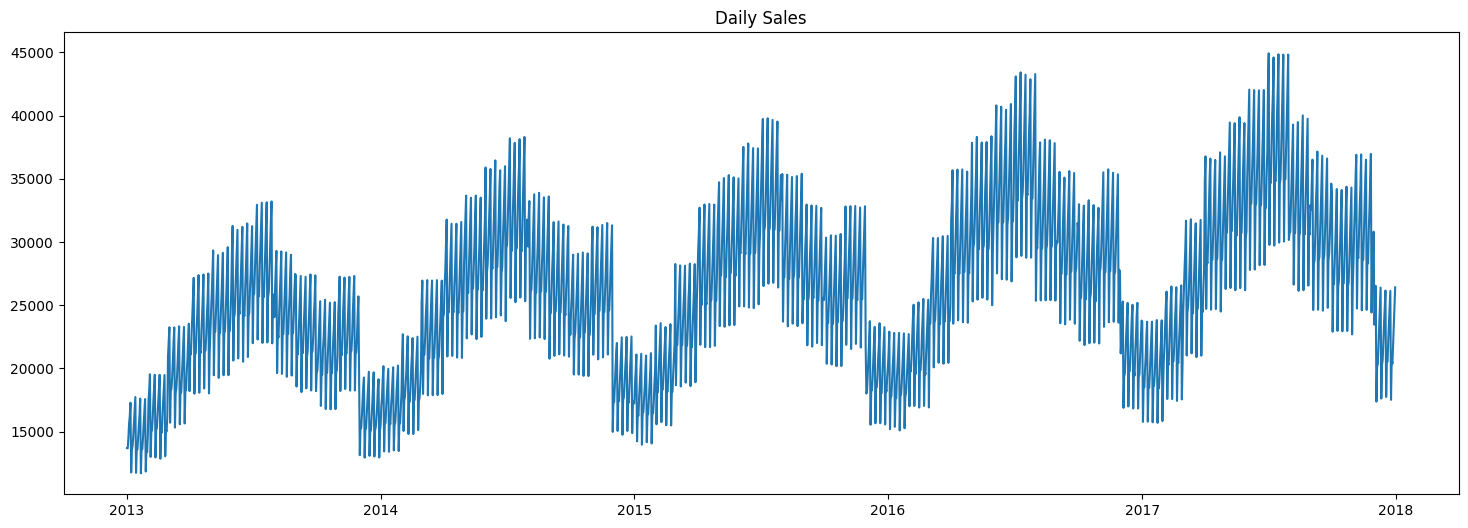

In [60]:
daily_sales = (
    train.groupby("date")["sales"]
    .sum()
)

plt.figure(figsize=(18,6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Sales")

plt.show()

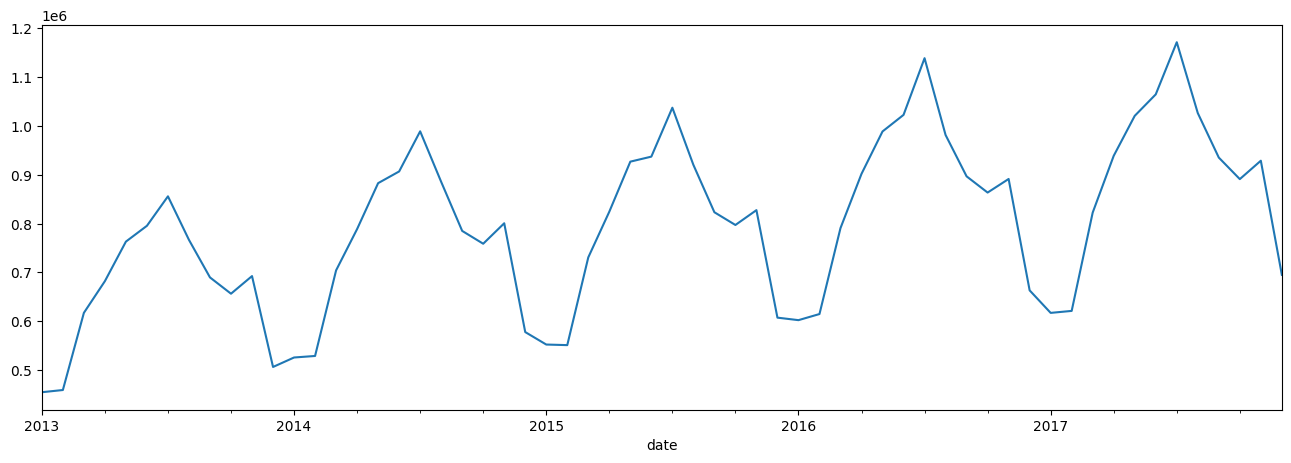

In [61]:
monthly = (
    train
    .groupby(
        train["date"].dt.to_period("M")
    )["sales"]
    .sum()
)

monthly.plot(figsize=(16,5))

plt.show()

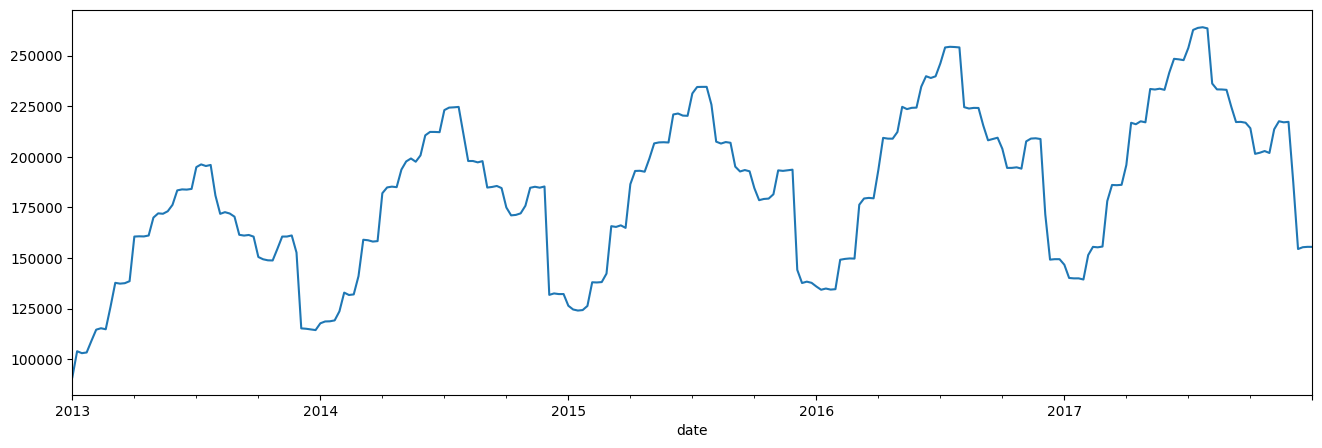

In [62]:
weekly = (
    train
    .groupby(
        train["date"].dt.to_period("W")
    )["sales"]
    .sum()
)

weekly.plot(figsize=(16,5))

plt.show()

In [63]:
test["sales"] = np.nan

df = pd.concat(
    [train,test],
    ignore_index=True
)

df.sort_values(
    ["store","item","date"],
    inplace=True
)

df.reset_index(drop=True,inplace=True)

In [64]:
df["year"] = df.date.dt.year

df["month"] = df.date.dt.month

df["day"] = df.date.dt.day

df["dayofweek"] = df.date.dt.dayofweek

df["weekofyear"] = (
    df.date.dt.isocalendar().week.astype(int)
)

df["quarter"] = df.date.dt.quarter

df["is_weekend"] = (
    df.dayofweek>=5
).astype(int)

df["dayofyear"] = df.date.dt.dayofyear

In [65]:
lags = [1,7,14,28,30,90]

for lag in lags:

    df[f"lag_{lag}"] = (

        df.groupby(["store","item"])["sales"]

        .transform(

            lambda x: x.shift(lag)

        )

    )

In [66]:
windows = [7, 14, 30, 90]

for window in windows:
    df[f"rolling_std_{window}"] = (
        df.groupby(["store", "item"])["sales"]
          .transform(
              lambda x: x.shift(1).rolling(window, min_periods=1).std()
          )
    )

In [67]:
for window in windows:

    df[f"rolling_std_{window}"] = (
        df.groupby(["store","item"])["sales"]
          .transform(
              lambda x: x.shift(1).rolling(window, min_periods=1).std()
          )
    )

In [68]:
windows = [7, 14, 30, 90]

for window in windows:
    df[f"rolling_mean_{window}"] = (
        df.groupby(["store", "item"])["sales"]
          .transform(
              lambda x: x.shift(1).rolling(window, min_periods=1).mean()
          )
    )

In [69]:
alphas = [0.95, 0.9, 0.8, 0.7]

for alpha in alphas:

    df[f"ema_{str(alpha).replace('.','')}"] = (

        df.groupby(["store","item"])["sales"]

        .transform(

            lambda x: x.shift(1).ewm(alpha=alpha).mean()

        )

    )

In [70]:
df["expanding_mean"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

In [33]:
# print(df.shape)

# print(train_df.shape)

# print(test_df.shape)

In [34]:
# print(X.shape)

In [35]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
id,913000
sales,45000
lag_14,45000
lag_7,45000
lag_1,45000
lag_90,45000
lag_30,45000
lag_28,45000
rolling_std_7,43000
rolling_mean_7,42000


In [71]:
# Split first
train_df = df[df["sales"].notna()].copy()
test_df = df[df["sales"].isna()].copy()

# Keep only rows where engineered features are available (LightGBM can handle NaNs directly)
# The feature_cols list is still useful for defining FEATURES later.
feature_cols = [col for col in train_df.columns if col not in ["sales", "date"]]

# Removed: train_df = train_df.dropna(subset=feature_cols).reset_index(drop=True)

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (913000, 32)
Test Shape : (45000, 32)


In [72]:
print(df.shape)

print(train_df.shape)

print(test_df.shape)

(958000, 32)
(913000, 32)
(45000, 32)


In [73]:
print(train_df.shape)

(913000, 32)


In [74]:
train_df = (
    df[df["sales"].notna()]
    .sort_values(["store","item","date"])
    .reset_index(drop=True)
)

test_df = (
    df[df["sales"].isna()]
    .sort_values(["store","item","date"])
    .reset_index(drop=True)
)

In [75]:
print(train_df.shape)

print(test_df.shape)

train_df.head()

(913000, 32)
(45000, 32)


,date,store,item,sales,id,year,month,day,dayofweek,weekofyear,quarter,is_weekend,dayofyear,lag_1,lag_7,lag_14,lag_28,lag_30,lag_90,rolling_std_7,rolling_std_14,rolling_std_30,rolling_std_90,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_mean_90,ema_095,ema_09,ema_08,ema_07,expanding_mean
0,2013-01-01,1,1,13.0,NaN,2013,1,1,1,1,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11.0,NaN,2013,1,2,2,1,1,0,2,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
2,2013-01-03,1,1,14.0,NaN,2013,1,3,3,1,1,0,3,11.0,NaN,NaN,NaN,NaN,NaN,1.414214,1.414214,1.414214,1.414214,12.000000,12.000000,12.000000,12.000000,11.095238,11.181818,11.333333,11.461538,12.000000
3,2013-01-04,1,1,13.0,NaN,2013,1,4,4,1,1,0,4,14.0,NaN,NaN,NaN,NaN,NaN,1.527525,1.527525,1.527525,1.527525,12.666667,12.666667,12.666667,12.666667,13.855107,13.720721,13.483871,13.287770,12.666667
4,2013-01-05,1,1,10.0,NaN,2013,1,5,5,1,1,1,5,13.0,NaN,NaN,NaN,NaN,NaN,1.258306,1.258306,1.258306,1.258306,12.750000,12.750000,12.750000,12.750000,13.042750,13.072007,13.096154,13.084686,12.750000


Part 2: Time-series split, LightGBM training, evaluation, model saving
Part 3: XGBoost
Part 4: ARIMA and SARIMA
Part 5: GRU
Part 6: Model comparison, SHAP, metrics export, inference

Part 2A: Time Series Split + LightGBM Training

In [76]:
print(train_df.isnull().sum().sort_values(ascending=False).head(15))

id                 913000
lag_90              45000
lag_30              15000
lag_28              14000
lag_14               7000
lag_7                3500
rolling_std_7        1000
rolling_std_14       1000
rolling_std_30       1000
rolling_std_90       1000
rolling_mean_7        500
lag_1                 500
ema_095               500
rolling_mean_90       500
rolling_mean_30       500
dtype: int64


In [77]:
# Uncomment if LightGBM is missing
# !pip install lightgbm

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

print("LightGBM Version:", lgb.__version__)

LightGBM Version: 4.6.0


In [78]:
N_SPLITS = 5

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [96]:
# lgb_params = {

#     "objective": "regression",

#     "metric": "rmse",

#     "boosting_type": "gbdt",

#     "learning_rate": 0.03,

#     "num_leaves": 31,

#     "max_depth": -1,

#     "feature_fraction": 0.85,

#     "bagging_fraction": 0.80,

#     "bagging_freq": 5,

#     "min_child_samples": 20,

#     "lambda_l1": 0.1,

#     "lambda_l2": 0.1,

#     "verbosity": -1,

#     "random_state": 42,

#     "n_estimators": 3000

# }

lgb_params = {

    "objective":"regression",

    "metric":"rmse",

    "boosting_type":"gbdt",

    "learning_rate":0.015,

    "n_estimators":6000,

    "num_leaves":127,

    "max_depth":12,

    "min_child_samples":40,

    "feature_fraction":0.90,

    "bagging_fraction":0.90,

    "bagging_freq":5,

    "lambda_l1":0.5,

    "lambda_l2":0.5,

    "min_gain_to_split":0.01,

    "verbosity":-1,

    "random_state":42,

    "n_jobs":-1
}

In [97]:
# print(X.shape)
# print(y.shape)

In [98]:
if "id" in train_df.columns:
    train_df = train_df.drop(columns=["id"])

if "id" in test_df.columns:
    test_ids = test_df["id"].copy()   # Save for later submission
    test_df = test_df.drop(columns=["id"])

In [99]:
TARGET = "sales"

DROP_COLUMNS = [
    "sales",
    "date"
]

if "id" in train_df.columns:
    DROP_COLUMNS.append("id")

FEATURES = [
    col
    for col in train_df.columns
    if col not in DROP_COLUMNS
]

print("Number of Features:", len(FEATURES))
print(FEATURES)

Number of Features: 29
['store', 'item', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend', 'dayofyear', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_30', 'lag_90', 'rolling_std_7', 'rolling_std_14', 'rolling_std_30', 'rolling_std_90', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_mean_90', 'ema_095', 'ema_09', 'ema_08', 'ema_07', 'expanding_mean']


In [142]:
X = train_df[FEATURES].copy()
y = train_df[TARGET].copy()

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (913000, 29)
y Shape: (913000,)


In [143]:
print(X.isnull().sum().sort_values(ascending=False).head(10))

lag_90            45000
lag_30            15000
lag_28            14000
lag_14             7000
lag_7              3500
rolling_std_7      1000
rolling_std_90     1000
rolling_std_30     1000
rolling_std_14     1000
rolling_mean_7      500
dtype: int64


In [144]:
models = []

oof_predictions = np.full(
    len(train_df),
    np.nan
)

fold_scores = []

training_times = []

for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), start=1):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = lgb.LGBMRegressor(
        **lgb_params
    )

    start = time.time()

    model.fit(

        X_train,
        y_train,

        eval_set=[
    (X_valid,y_valid)],

        eval_metric="rmse",

        callbacks=[

            lgb.early_stopping(100),

            lgb.log_evaluation(100)

        ]

    )

    end = time.time()

    train_time = end - start

    training_times.append(train_time)

    preds = model.predict(
        X_valid,
        num_iteration=model.best_iteration_
    )

    oof_predictions[valid_idx] = preds

    models.append(model)

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            preds
        )
    )

    fold_scores.append(rmse)

    print(f"Fold RMSE : {rmse:.4f}")

    print(f"Training Time : {train_time:.2f} sec")

Fold 1
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 10.6182
[200]	valid_0's rmse: 8.24133
[300]	valid_0's rmse: 8.01119
[400]	valid_0's rmse: 7.9577
[500]	valid_0's rmse: 7.93221
[600]	valid_0's rmse: 7.91758
[700]	valid_0's rmse: 7.90956
[800]	valid_0's rmse: 7.90202
[900]	valid_0's rmse: 7.89626
[1000]	valid_0's rmse: 7.89256
[1100]	valid_0's rmse: 7.88921
[1200]	valid_0's rmse: 7.88801
[1300]	valid_0's rmse: 7.88719
[1400]	valid_0's rmse: 7.88639
[1500]	valid_0's rmse: 7.88673
Early stopping, best iteration is:
[1410]	valid_0's rmse: 7.88623
Fold RMSE : 7.8862
Training Time : 38.16 sec
Fold 2
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 9.42764
[200]	valid_0's rmse: 7.24942
[300]	valid_0's rmse: 7.04172
[400]	valid_0's rmse: 6.99342
[500]	valid_0's rmse: 6.97086
[600]	valid_0's rmse: 6.95579
[700]	valid_0's rmse: 6.94433
[800]	valid_0's rmse: 6.93646
[900]	valid_0's rmse: 6.92904
[1000]	valid_0's rmse: 6.9

In [145]:
best_fold = np.argmin(fold_scores)

best_model = models[best_fold]

print("Best Fold :", best_fold + 1)

print("Best RMSE :", fold_scores[best_fold])

Best Fold : 3
Best RMSE : 6.325762261273858


In [146]:
summary = pd.DataFrame({

    "Fold":

        np.arange(1, N_SPLITS + 1),

    "RMSE":

        fold_scores,

    "Training Time":

        training_times

})

summary

,Fold,RMSE,Training Time
0,1,7.886226,38.162698
1,2,6.892455,110.103362
2,3,6.325762,180.547252
3,4,7.645037,131.795007
4,5,7.662532,207.698621


In [147]:
print("Average RMSE :", np.mean(fold_scores))
print("Std RMSE :", np.std(fold_scores))

Average RMSE : 7.282402203006052
Std RMSE : 0.5844355078842279


In [148]:
importance = pd.DataFrame({

    "Feature": FEATURES,

    "Importance":

        best_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
28,expanding_mean,27558
15,lag_90,27008
16,rolling_std_7,25419
11,lag_7,25107
12,lag_14,24983
13,lag_28,24794
20,rolling_mean_7,24313
14,lag_30,24051
9,dayofyear,23545
17,rolling_std_14,22865


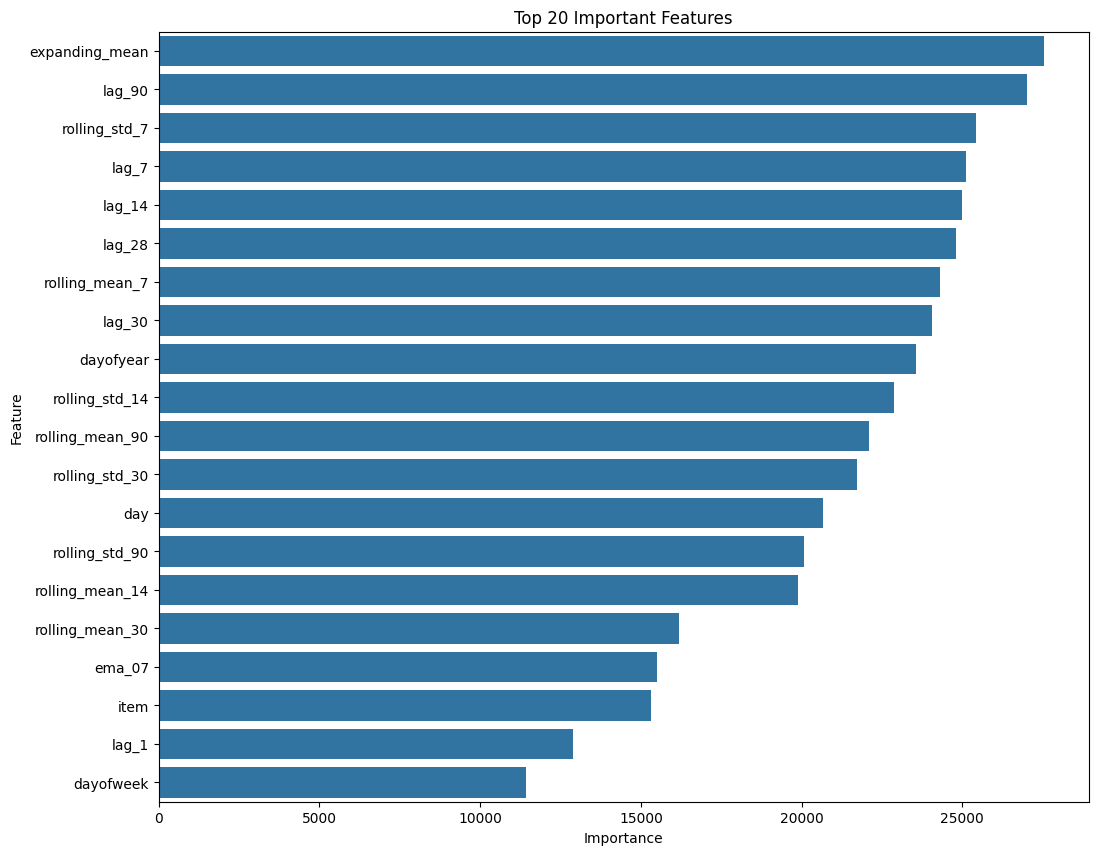

In [149]:
plt.figure(figsize=(12,10))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [150]:
importance.to_csv(

    "lightgbm_feature_importance.csv",

    index=False

)

print("Saved Feature Importance")

Saved Feature Importance


In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [152]:
valid_mask = ~np.isnan(oof_predictions)

y_true = y.iloc[valid_mask]

y_pred = oof_predictions[valid_mask]

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

rmsle = np.sqrt(
    mean_squared_error(
        np.log1p(y_true),
        np.log1p(np.maximum(y_pred,0))
    )
)

mask = y_true != 0

mape = np.mean(
    np.abs(
        (y_true[mask]-y_pred[mask])/
        y_true[mask]
    )
)*100

r2 = r2_score(
    y_true,
    y_pred
)

metrics = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "RMSLE",
        "MAPE (%)",
        "R²"
    ],

    "Value":[
        mae,
        rmse,
        rmsle,
        mape,
        r2
    ]

})

metrics

,Metric,Value
0,MAE,5.619529
1,RMSE,7.305816
2,RMSLE,0.165330
3,MAPE (%),13.492262
4,R²,0.933632


In [153]:
print("=" * 60)
print("LightGBM Evaluation Metrics")
print("=" * 60)

print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RMSLE  : {rmsle:.4f}")
print(f"MAPE   : {mape:.2f}%")
print(f"R²     : {r2:.4f}")

LightGBM Evaluation Metrics
MAE    : 5.6195
RMSE   : 7.3058
RMSLE  : 0.1653
MAPE   : 13.49%
R²     : 0.9336


In [154]:
metrics.to_csv(
    "lightgbm_metrics.csv",
    index=False
)

print("Metrics saved successfully.")

Metrics saved successfully.


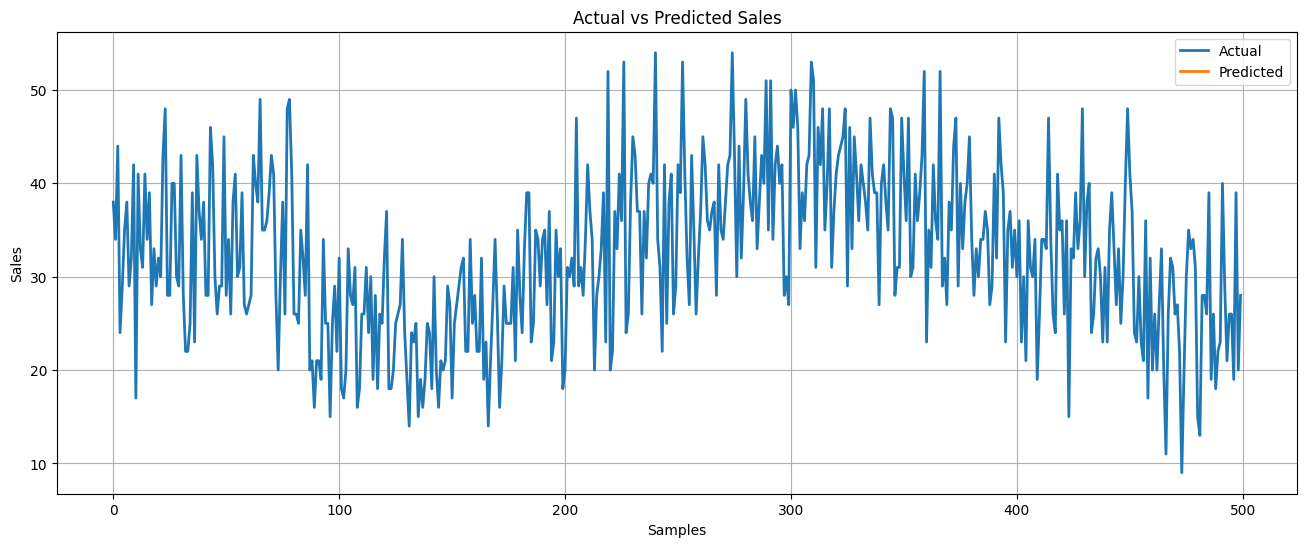

In [155]:
plt.figure(figsize=(16,6))

plt.plot(
    y_true.iloc[:500].values,
    label="Actual",
    linewidth=2
)

plt.plot(
    oof_predictions[:500],
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

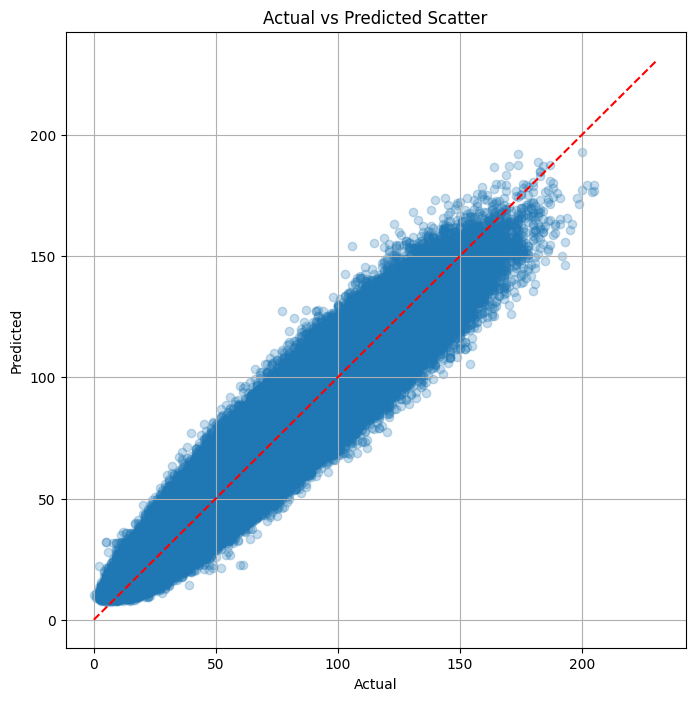

In [156]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.25
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted Scatter")

plt.grid(True)

plt.show()

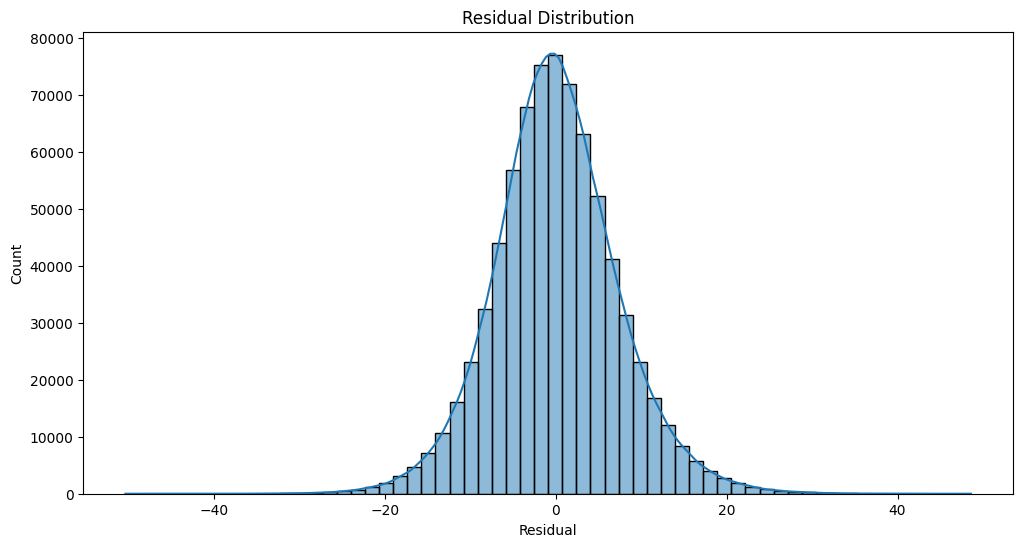

In [157]:
residuals = y_true - y_pred

plt.figure(figsize=(12,6))

sns.histplot(
    residuals,
    bins=60,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

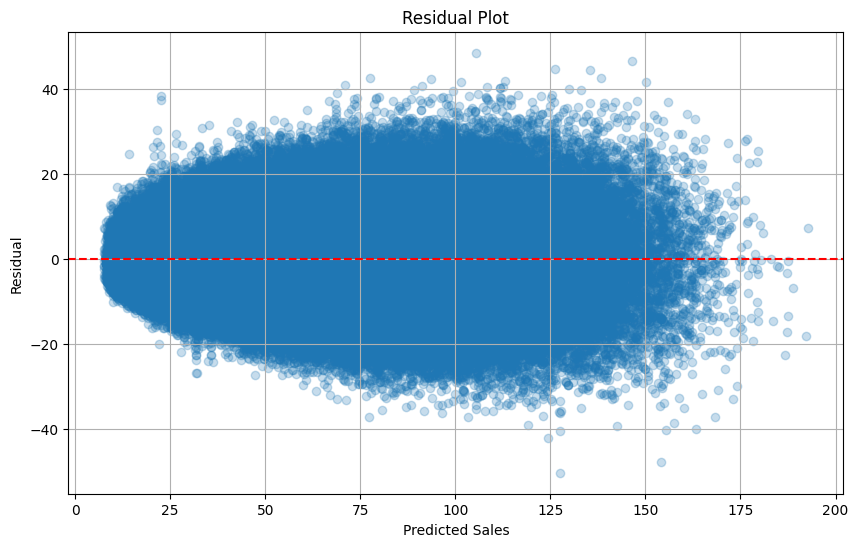

In [169]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.25
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [159]:
importance = pd.DataFrame({

    "Feature": FEATURES,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
28,expanding_mean,27558
15,lag_90,27008
16,rolling_std_7,25419
11,lag_7,25107
12,lag_14,24983
13,lag_28,24794
20,rolling_mean_7,24313
14,lag_30,24051
9,dayofyear,23545
17,rolling_std_14,22865


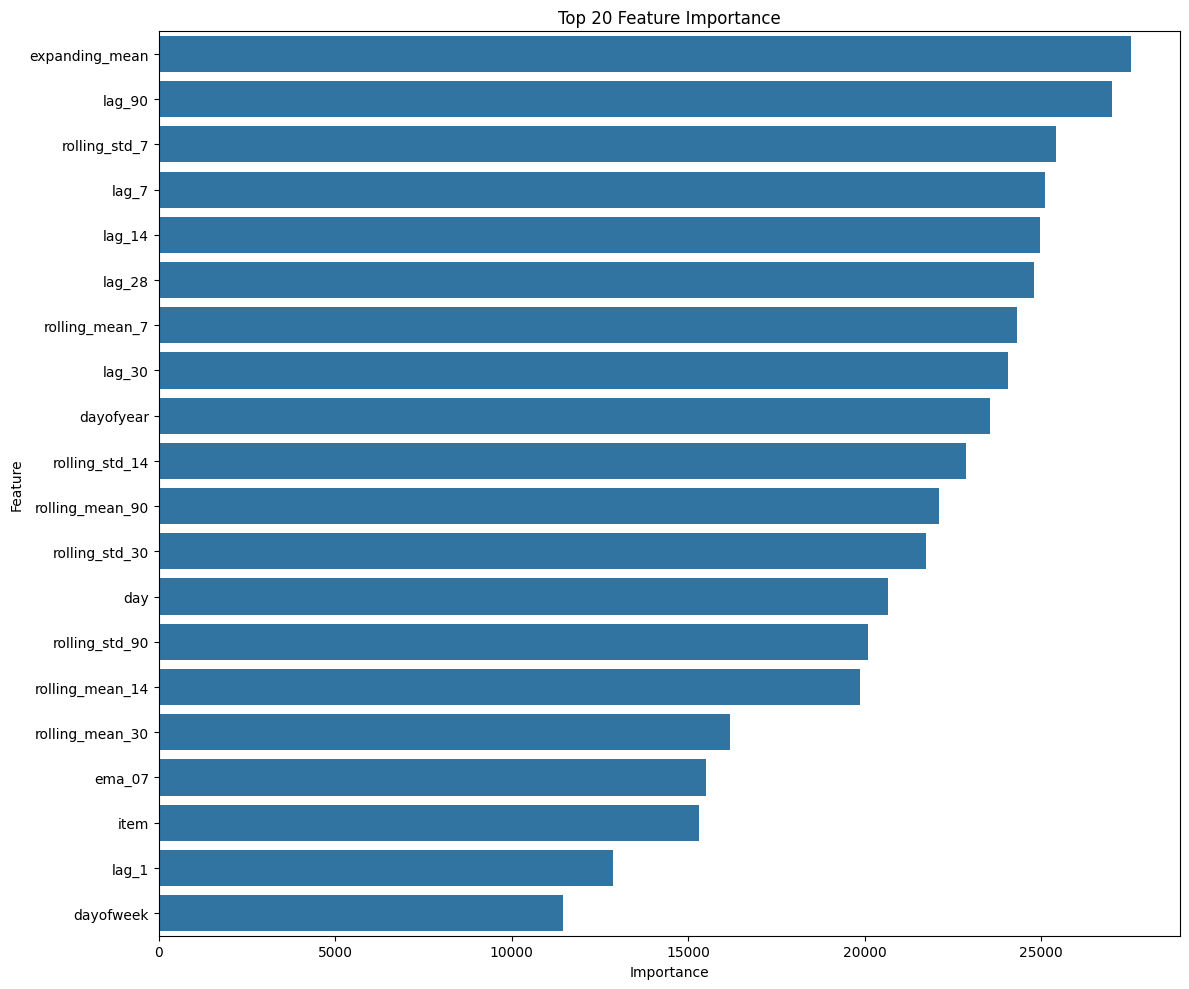

In [160]:
plt.figure(figsize=(12,10))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Feature Importance")

plt.tight_layout()

plt.show()

In [161]:
importance.to_csv(
    "lightgbm_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [162]:
import joblib

joblib.dump(
    best_model,
    "lightgbm_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [163]:
joblib.dump(
    FEATURES,
    "feature_columns.pkl"
)

print("Feature list saved.")

Feature list saved.


In [164]:
import json

with open("lightgbm_params.json", "w") as f:
    json.dump(
        lgb_params,
        f,
        indent=4
    )

print("Parameters saved.")

Parameters saved.


In [165]:
import json

with open("lightgbm_params.json", "w") as f:
    json.dump(
        lgb_params,
        f,
        indent=4
    )

print("Parameters saved.")

Parameters saved.


In [166]:
validation_predictions = pd.DataFrame({

    "Actual": y_true.values,

    "Predicted": y_pred,

    "Residual": y_true.values-y_pred

})
validation_predictions.to_csv(

    "validation_predictions.csv",

    index=False

)

validation_predictions.head()

,Actual,Predicted,Residual
0,38.0,33.494554,4.505446
1,34.0,36.950668,-2.950668
2,44.0,39.212297,4.787703
3,24.0,26.277830,-2.277830
4,29.0,30.965423,-1.965423


In [167]:
sample = X.iloc[:5]

predictions = best_model.predict(sample)

prediction_df = pd.DataFrame({

    "Predicted Sales": predictions

})

prediction_df

,Predicted Sales
0,18.495611
1,13.159440
2,12.386445
3,13.135051
4,13.755247


In [168]:
sample = X.iloc[:5]

predictions = best_model.predict(sample)

prediction_df = pd.DataFrame({

    "Predicted Sales": predictions

})

prediction_df

,Predicted Sales
0,18.495611
1,13.159440
2,12.386445
3,13.135051
4,13.755247
